# Dataset Preparation

This notebook contains code for extraction of `15` classes of fruits from  `Fruits-360` dataset containing `257` different fruits.

The 15 fruits of choice that will be used in image classification are: 

1. Apple 8 

2. Carambola 1

3. Guava 1 

4. Orange 1 

5. Rambutan 1 

6. Banana Lady Finger 1 

7. Dates 1 

8. Kiwi 1 

9. Pepper 2 

10. Strawberry 1 

11. Blueberry 1 

12. Fig 1 

13. Mango 1 

14. Pineapple 1 

15. Watermelon 1



## Define Fruits to Extract
Defines the list of 15 fruit classes to be extracted from the original Fruits-360 dataset.


In [ ]:
FRUITS_TO_EXTRACT = [
    "Apple 8",
    "Carambola 1",
    "Guava 1",
    "Orange 1",
    "Rambutan 1",
    "Banana Lady Finger 1",
    "Dates 1",
    "Kiwi 1",
    "Pepper 2",
    "Strawberry 1",
    "Blueberry 1",
    "Fig 1",
    "Mango 1",
    "Pineapple 1",
    "Watermelon 1",
]


In [ ]:
# NOTE: REMEMBER TO REMOVE
# Debug Print Statement
print("=" * 50)


## Import Required Libraries
 
Imports the necessary libraries for file and directory operations:

 `os` for file system operations and 
 
 `shutil` for copying files and directories.

In [ ]:
import os
import shutil

import random

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from PIL import Image
import cv2

# Silence TF info / warning noise (optional)
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"


## Set Dataset Paths and Check Source

Set the source and destination paths for the dataset,  
Defines subdirectories, and checks if the source path exists.

In [ ]:
# Test the path of the root folder
# SOURCE_PATH = "dataset/fruits-360"
# DATASET_PATH = "dataset/fruits_dataset"
SOURCE_PATH = "/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360"
DATASET_PATH = "/kaggle/working/fruits_dataset"
SUB_DIRECTORIES = ["Training", "Test"]

if os.path.exists(SOURCE_PATH):
    print(f"Source path exits: {SOURCE_PATH}")

if os.path.exists(os.path.join(SOURCE_PATH, SUB_DIRECTORIES[0])):
    print(f"Training path exists: {os.path.join(SOURCE_PATH, SUB_DIRECTORIES[0])}")
if os.path.exists(os.path.join(SOURCE_PATH, SUB_DIRECTORIES[1])):
    print(f"Test path exists: {os.path.join(SOURCE_PATH, SUB_DIRECTORIES[1])}")


Source path exits: /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360
Training path exists: /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training
Test path exists: /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test


## Extract Chosen Fruit Classes Function

A helper function to extract only the selected fruit classes from the source dataset and copy them to a new destination directory, preserving the train/test structure.

In [ ]:
def extract_chosen_fruits(source_path, dest_path, classes_choice, verbose=False):
    """
    This function extracts specific fruit class directories from a source dataset
    and replicates the structure in a new destination directory.

    Input Args:
    source_path: The root directory path containing the original 'Training' and 'Test' folders.
    dest_path: The target root directory where the selected fruits will be copied.
    classes_choice: A list of strings representing the specific fruit folder names to extract.
    verbose: Boolean flag to enable detailed logging of each copy operation.

    Return:
    None. Outputs a summary of copied directories to the console.
    """

    # Helper for cleaner conditional printing
    def vprint(message):
        if verbose:
            print(message)

    # Basic validation for destination path
    if not dest_path or not dest_path.strip():
        print("Error: Destination path not provided.")
        return

    # ==================== Pre-copy Check ====================
    if os.path.exists(dest_path):
        print(f"Error: Destination Folder '{dest_path}' already exists.")
        print("Skipping extraction to avoid overwriting data.")
        print("=" * 50)
        return

    print("=" * 50)
    print(f"SOURCE ROOT:      {os.path.abspath(source_path)}")
    print(f"DESTINATION ROOT: {os.path.abspath(dest_path)}")
    print("=" * 50, end="\n\n")

    for sub_dir in SUB_DIRECTORIES:
        sub_dir_source = os.path.join(source_path, sub_dir)

        if not os.path.exists(sub_dir_source):
            print(f"Skipping {sub_dir}: Directory not found in source.")
            continue

        print(f"---- Processing Sub-directory: {sub_dir} ----")

        successful_copied_counter = 0

        for fruit in classes_choice:
            src_fruit_path = os.path.join(sub_dir_source, fruit)
            dst_fruit_path = os.path.join(dest_path, sub_dir, fruit)

            if os.path.exists(src_fruit_path):
                # Ensure the parent directory (Training/Test) exists in destination
                os.makedirs(os.path.dirname(dst_fruit_path), exist_ok=True)

                # Copy the entire directory tree
                shutil.copytree(src_fruit_path, dst_fruit_path, dirs_exist_ok=True)
                successful_copied_counter += 1
                vprint(f"  [OK] Copied: {fruit}")
            else:
                print(f"  [!] Missing: {fruit} (not found in {sub_dir})")

        print(f"\nSummary for {sub_dir}:")
        print(f"Total folders successfully copied: {successful_copied_counter}")
        print("=" * 50, end="\n\n")

    print("==== EXTRACTION PROCESS COMPLETE ====")


## Initialize Class Names List

Initializes an empty list to store the simplified class names after renaming.

In [ ]:
CLASS_NAMES = []


## Rename Fruit Class Folders
A helper function to rename the extracted fruit class folders to their base fruit names in lowercase (e.g., 'Banana Lady Finger 1' to 'banana').

In [ ]:
def rename_fruit_class_name(dataset_path, verbose=False):
    """
    This function renames long class directories to their base fruit name in lowercase.
    For example: "Banana Lady Finger 1" is converted to "banana".

    Input Args:
    dataset_path: The path to the directory containing the fruit folders.
    verbose: Boolean flag to enable detailed logging of each rename operation.

    Return:
    None. The function modifies the directory names on the disk.
    """

    # Helper for cleaner conditional printing
    def vprint(message):
        if verbose:
            print(message)

    if not dataset_path or not dataset_path.strip():
        print("Error: Dataset path not provided")
        return

    vprint("=" * 50)
    vprint(f"RENAMING CLASSES IN: {dataset_path}")
    vprint("=" * 50)

    rename_counter = 0

    for class_name in FRUITS_TO_EXTRACT:
        # Generate the new name (e.g., "apple")
        new_name = class_name.split(" ")[0].lower()

        # Update global list regardless of whether rename happens
        if new_name not in CLASS_NAMES:
            CLASS_NAMES.append(new_name)

        old_path = os.path.join(dataset_path, class_name)
        new_path = os.path.join(dataset_path, new_name)

        # Logic for renaming
        if os.path.exists(old_path) and not os.path.exists(new_path):
            os.rename(old_path, new_path)
            rename_counter += 1
            vprint(f"[RENAME] {class_name} -> {new_name}")
        elif os.path.exists(new_path):
            vprint(f"[EXISTS] Skipping: '{new_name}' already exists.")
        else:
            print(f"[MISSING] Source '{class_name}' not found.")

    vprint("-" * 60)
    print(f"Total folders renamed in {dataset_path}: {rename_counter}")
    print("=" * 60)


## Ensure All Classes Exist Function

A helper function to check if all expected fruit class folders exist in a given directory, helping to verify data integrity after extraction and renaming.

In [ ]:
def ensure_class_exists(directory, sub_folder_list, verbose=False):
    """
    This function ensures that a given list of sub-folders (fruit classes) actually
    exists within the specified directory. It serves as a data integrity check.

    Input Args:
    directory: The path to the parent folder (e.g., TRAIN_DIR or TEST_DIR).
    sub_folder_list: A list of strings representing the expected class folder names.
    verbose: Boolean flag to enable detailed logging.

    Return:
    A boolean value. True if all folders exist, False if at least one is missing.
    """

    # Helper function: Only prints if verbose is True
    def vprint(message):
        if verbose:
            print(message)

    vprint("=" * 50)
    vprint(f"VALIDATING CLASSES IN: {directory}")
    vprint("=" * 50)

    missing_folders = []

    for sub_folder in sub_folder_list:
        folder_path = os.path.join(directory, sub_folder)

        # Using isdir to look for class folders
        if not os.path.isdir(folder_path):
            missing_folders.append(sub_folder)
            print(f"[MISSING]: {sub_folder}")
        else:
            vprint(f"[FOUND]: {sub_folder}")

    vprint("-" * 50)

    if not missing_folders:
        vprint(f"Success: All {len(sub_folder_list)} classes are present.")
        vprint("=" * 50)
        return True
    else:
        print(f"Warning: {len(missing_folders)} classes missing from {directory}.")
        print("=" * 50)
        return False


# Raw Data EDA

## Visualize Random Samples Function
A helper function to display one random sample image from each fruit class folder.

In [ ]:
def visualize_random_samples(dataset_path="", set_name="Dataset", seed=42):
    """
    Displays a grid of one random sample image from each class folder.

    Input Args:
    dataset_path: Path to the directory (e.g., TRAIN_DIR or TEST_DIR).
    set_name: Name of the set for the title.

    Return:
    None. Displays a matplotlib grid.
    """
    classes = sorted(
        [
            d
            for d in os.listdir(dataset_path)
            if os.path.isdir(os.path.join(dataset_path, d))
        ]
    )
    num_classes = len(classes)

    # Determine grid size (rows x cols)
    cols = 5
    rows = (num_classes // cols) + (1 if num_classes % cols != 0 else 0)

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
    fig.suptitle(f"Random Samples from {set_name}", fontsize=20, y=1.02)
    axes = axes.flatten()

    for i, class_name in enumerate(classes):
        class_folder = os.path.join(dataset_path, class_name)
        images = [
            f
            for f in os.listdir(class_folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        random.seed(seed)
        if images:
            img_path = os.path.join(class_folder, random.choice(images))
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(class_name)

        axes[i].axis("off")

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


## Visualize Class Distribution Function

A helper function to count the number of images in each class folder and display the class distribution

In [ ]:
def visualize_class_distribution(dataset_path, set_name="Dataset"):
    """
    Counts the number of images in each class folder and displays a bar chart.

    Input Args:
    dataset_path: Path to the directory (e.g., TRAIN_DIR or TEST_DIR).
    set_name: Name of the set for the title (e.g., "Training Set").

    Return:
    None. Displays a matplotlib plot.
    """
    # Get class names and count files in each
    classes = sorted(
        [
            d
            for d in os.listdir(dataset_path)
            if os.path.isdir(os.path.join(dataset_path, d))
        ]
    )
    counts = [len(os.listdir(os.path.join(dataset_path, c))) for c in classes]

    # Create the plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(classes, counts, color="skyblue", edgecolor="navy")

    plt.title(f"Class Distribution: {set_name}", fontsize=16)
    plt.xlabel("Fruit Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(rotation=45, ha="right")

    # Add counts on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, yval + 1, yval, ha="center", va="bottom"
        )

    plt.tight_layout()
    plt.show()


# Data Pre-processsing 

In [ ]:
# Set Training and Test Directory Paths
TRAIN_DIR = os.path.join(DATASET_PATH, SUB_DIRECTORIES[0])
TEST_DIR = os.path.join(DATASET_PATH, SUB_DIRECTORIES[1])
print(f"Training Data Path: {TRAIN_DIR}")
print(f"Test Data Path: {TEST_DIR}")


Training Data Path: /kaggle/working/fruits_dataset/Training
Test Data Path: /kaggle/working/fruits_dataset/Test


In [ ]:
# Extracting 15 fruts class from the dataset
extract_chosen_fruits(SOURCE_PATH, DATASET_PATH, FRUITS_TO_EXTRACT)


SOURCE ROOT:      /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360
DESTINATION ROOT: /kaggle/working/fruits_dataset

---- Processing Sub-directory: Training ----

Summary for Training:
Total folders successfully copied: 15

---- Processing Sub-directory: Test ----

Summary for Test:
Total folders successfully copied: 15

==== EXTRACTION PROCESS COMPLETE ====


In [ ]:
# rename folder with base fruit name
rename_fruit_class_name(TRAIN_DIR)
rename_fruit_class_name(TEST_DIR)


Total folders renamed in /kaggle/working/fruits_dataset/Training: 15
Total folders renamed in /kaggle/working/fruits_dataset/Test: 15


In [ ]:
# Display total number of classes
print(f"Total number of fruits classes: {len(CLASS_NAMES)}")
print(CLASS_NAMES)
NUM_CLASSES = len(CLASS_NAMES)


Total number of fruits classes: 15
['apple', 'carambola', 'guava', 'orange', 'rambutan', 'banana', 'dates', 'kiwi', 'pepper', 'strawberry', 'blueberry', 'fig', 'mango', 'pineapple', 'watermelon']


In [ ]:
# Check if all the fruit classes are present in train and test data
train_ensure_result = ensure_class_exists(TRAIN_DIR, CLASS_NAMES, False)
test_ensure_result = ensure_class_exists(TEST_DIR, CLASS_NAMES, False)

print(
    f"All classes are {'present' if train_ensure_result else 'not present'} in {TRAIN_DIR}"
)
print(
    f"All classes are {'present' if test_ensure_result else 'not present'} in {TEST_DIR}"
)


All classes are present in /kaggle/working/fruits_dataset/Training
All classes are present in /kaggle/working/fruits_dataset/Test


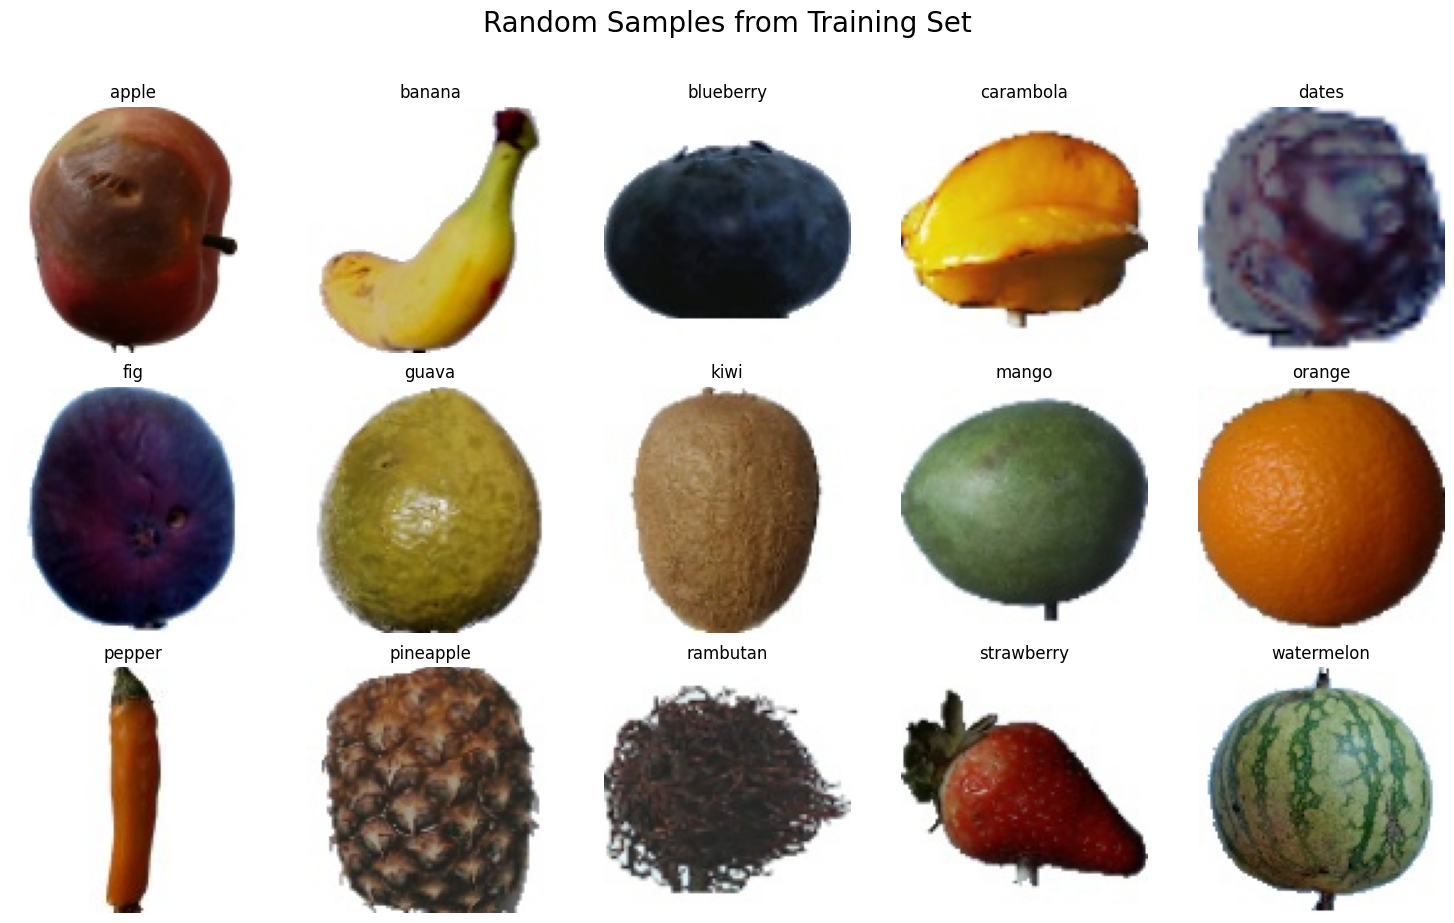

In [ ]:
# See one random sample fruit from each class in training data
visualize_random_samples(dataset_path=TRAIN_DIR, set_name="Training Set", seed=42)


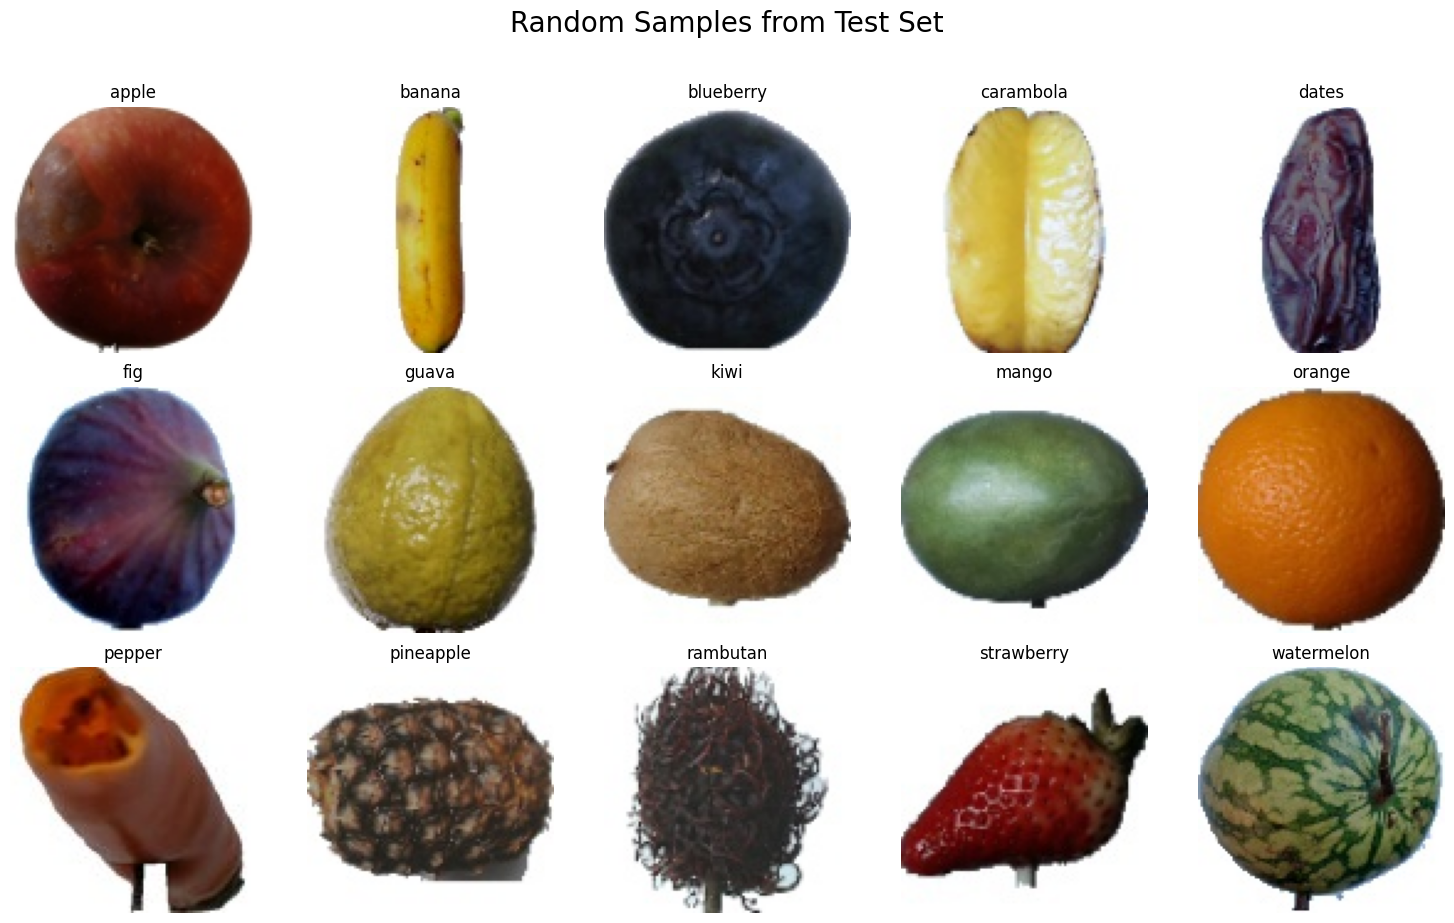

In [ ]:
# See one random sample fruit from each class in test data
visualize_random_samples(TEST_DIR, "Test Set", 24)


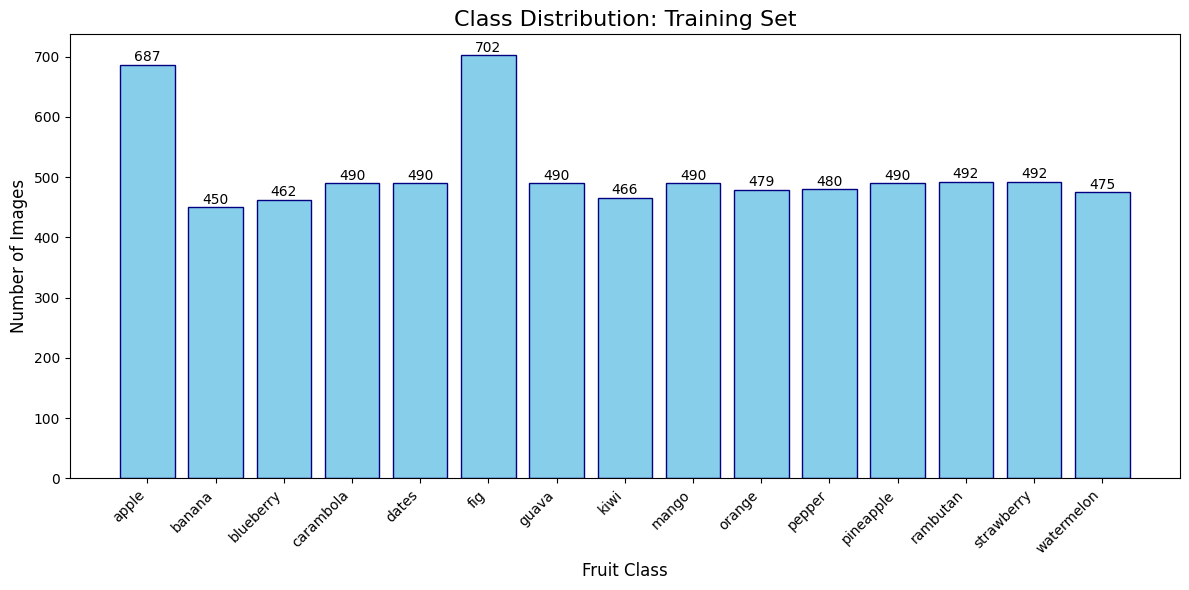

In [ ]:
# See class distribution of Trainig Data
visualize_class_distribution(TRAIN_DIR, "Training Set")


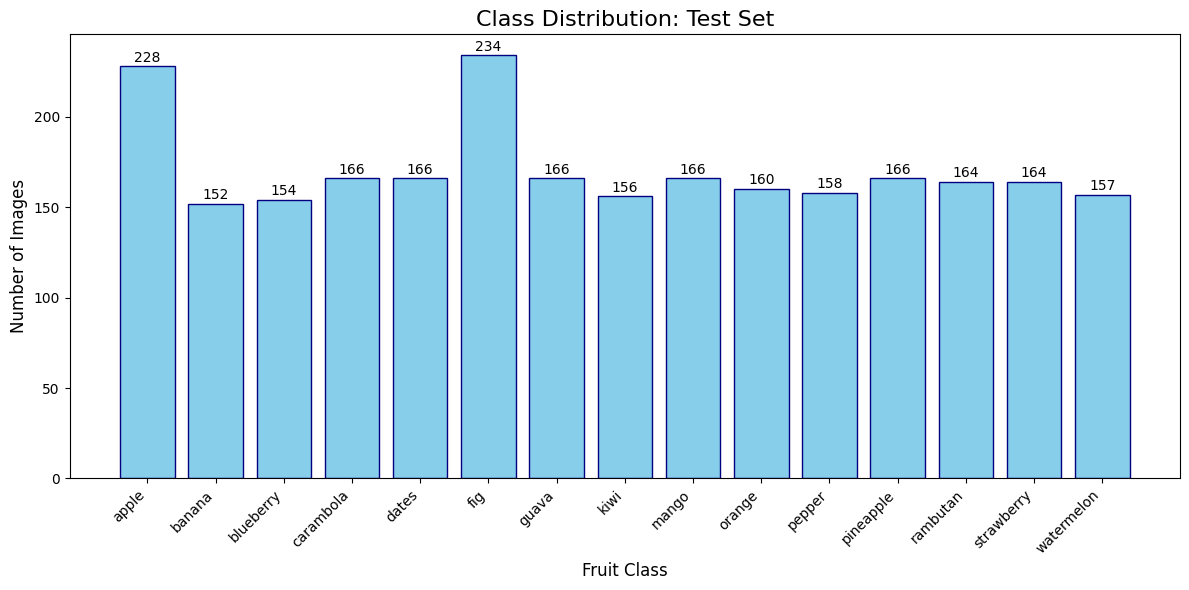

In [ ]:
# See class distribution of Test Data
visualize_class_distribution(TEST_DIR, "Test Set")


---

# Image Augmentation.py

Following code brings every class folder up to `TARGET_SIZE` images using a randomised  
mix of augmentations.


In [ ]:
TARGET_SIZE = 1000  # images per class after augmentation
IMAGE_EXTS = (".jpg", ".jpeg", ".png")  # accepted source extensions
SAVE_FORMAT = "JPEG"  # format for augmented images saved to disk
SAVE_EXT = ".jpg"  # file extension matching SAVE_FORMAT
JPEG_QUALITY = 95  # quality for JPEG saves (1-95)

# Augmentation intensity knobs
NOISE_STD_RANGE = (5.0, 18.0)  # Gaussian noise std (pixel units 0-255)
BLUR_KERNEL_SIZES = [3, 5]  # Gaussian blur kernel side-lengths (odd)
BLUR_SIGMA_RANGE = (0.5, 1.5)  # Gaussian blur sigma
ROTATION_RANGE_DEG = (-20, 20)  # random rotation in degrees
BRIGHTNESS_DELTA = 0.20  # max brightness shift  (TF uses 0-1)
CONTRAST_RANGE = (0.80, 1.20)  # contrast scale factor
ZOOM_RANGE = (0.85, 1.00)  # central crop fraction (< 1 = zoom-in)
TRANSLATE_FRACTION = 0.08  # max translation as fraction of dimension

# Each augmented image draws MIN_TRANSFORMS..MAX_TRANSFORMS unique entries
# from this pool, applied in a freshly shuffled order.
TRANSFORM_POOL = [
    "flip_horizontal",
    "rotate",
    "brightness",
    "contrast",
    "zoom",
    "translate",
    "gaussian_noise",
    "gaussian_blur",
]
MIN_TRANSFORMS = 3  # minimum transforms applied per image
MAX_TRANSFORMS = 5  # maximum transforms applied per image


## Helper Functions

In [ ]:
def load_image(image_path):
    """
    Load an image from disk and return a float32 tensor in [0, 255].

    We keep pixel values in [0, 255] throughout so that Gaussian noise
    std values are interpretable in absolute pixel units.  Values are
    clipped back to [0, 255] after each transform.
    """
    raw = tf.io.read_file(image_path)
    # decode_image handles JPEG / PNG / BMP automatically
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.cast(image, tf.float32)  # → [0.0, 255.0]
    return image


In [ ]:
def _apply_gaussian_blur(img, ksize, sigma):
    """
    Apply Gaussian blur using OpenCV.

    Args:
        img   : tf.Tensor (H, W, 3), float32 in [0, 255]
        ksize : kernel size (must be odd)
        sigma : standard deviation

    Returns:
        tf.Tensor (H, W, 3), float32
    """
    # Ensure kernel size is odd (cv2 requirement)
    if ksize % 2 == 0:
        ksize += 1

    def _cv2_blur(x):
        x = x.astype(np.float32)
        blurred = cv2.GaussianBlur(x, (ksize, ksize), sigma)
        return blurred.astype(np.float32)

    # Use tf.numpy_function to bridge TF ↔ NumPy/OpenCV
    blurred = tf.numpy_function(_cv2_blur, [img], tf.float32)

    # Restore shape (important, otherwise shape becomes unknown)
    blurred.set_shape(img.shape)

    return blurred


In [ ]:
def augment_image(image, seed=None):
    """
    Apply a randomised set of augmentations to a single image tensor.

    All transforms live in a single unified pool (TRANSFORM_POOL).
    Each call randomly selects MIN_TRANSFORMS..MAX_TRANSFORMS UNIQUE transforms
    and applies them in a freshly shuffled order.  No transform is applied
    more than once per image.  Gaussian noise and blur are now optional pool
    members, not mandatory pre-steps.

    Args:
        image : float32 tensor (H, W, 3) in [0, 255]
        seed  : optional integer for reproducibility (useful for debugging)

    Returns:
        Augmented float32 tensor (H, W, 3) in [0, 255]
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    img = image  # working copy; shape (H, W, 3)

    # ── Pick a random number of unique transforms (3–5) in random order ──────
    n_transforms = random.randint(MIN_TRANSFORMS, MAX_TRANSFORMS)
    chosen = random.sample(TRANSFORM_POOL, k=min(n_transforms, len(TRANSFORM_POOL)))

    for transform in chosen:

        if transform == "flip_horizontal":
            # Safe for fruit images (symmetric appearance)
            img = tf.image.flip_left_right(img)

        elif transform == "rotate":
            import cv2

            angle_deg = random.uniform(*ROTATION_RANGE_DEG)
            h, w = img.shape[0], img.shape[1]
            center = (w / 2.0, h / 2.0)

            M = cv2.getRotationMatrix2D(center, angle_deg, scale=1.0)

            rotated = cv2.warpAffine(
                img.numpy().astype(np.uint8),
                M,
                (w, h),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_CONSTANT,
                borderValue=(255, 255, 255),  # Fills empty space with black
            )

            img = tf.cast(rotated, tf.float32)
            img = tf.clip_by_value(img, 0.0, 255.0)

        elif transform == "brightness":
            # TF expects [0, 1]; rescale, adjust, rescale back
            delta = random.uniform(-BRIGHTNESS_DELTA, BRIGHTNESS_DELTA)
            img = img / 255.0
            img = tf.image.adjust_brightness(img, delta)
            img = img * 255.0
            img = tf.clip_by_value(img, 0.0, 255.0)

        elif transform == "contrast":
            factor = random.uniform(*CONTRAST_RANGE)
            img = img / 255.0
            img = tf.image.adjust_contrast(img, factor)
            img = img * 255.0
            img = tf.clip_by_value(img, 0.0, 255.0)

        elif transform == "zoom":
            # Simulate zoom-in via central crop then resize back
            frac = random.uniform(*ZOOM_RANGE)
            h, w = tf.shape(img)[0], tf.shape(img)[1]
            crop_h = tf.cast(tf.cast(h, tf.float32) * frac, tf.int32)
            crop_w = tf.cast(tf.cast(w, tf.float32) * frac, tf.int32)
            img = tf.image.resize_with_crop_or_pad(img, crop_h, crop_w)
            img = tf.image.resize(img, [h, w])
            img = tf.clip_by_value(img, 0.0, 255.0)

        elif transform == "translate":
            import cv2

            h = img.shape[0]
            w = img.shape[1]
            dy = random.uniform(-TRANSLATE_FRACTION, TRANSLATE_FRACTION) * h
            dx = random.uniform(-TRANSLATE_FRACTION, TRANSLATE_FRACTION) * w
            M = np.float32([[1, 0, dx], [0, 1, dy]])
            shifted = cv2.warpAffine(
                img.numpy().astype(np.uint8),
                M,
                (w, h),
                borderMode=cv2.BORDER_REFLECT_101,
            )
            img = tf.cast(shifted, tf.float32)
            img = tf.clip_by_value(img, 0.0, 255.0)

        elif transform == "gaussian_noise":
            std = random.uniform(*NOISE_STD_RANGE)
            noise = tf.random.normal(
                shape=tf.shape(img), mean=0.0, stddev=std, dtype=tf.float32
            )
            img = img + noise
            img = tf.clip_by_value(img, 0.0, 255.0)

        elif transform == "gaussian_blur":
            ksize = random.choice(BLUR_KERNEL_SIZES)
            sigma = random.uniform(*BLUR_SIGMA_RANGE)
            img = _apply_gaussian_blur(img, ksize, sigma)
            img = tf.clip_by_value(img, 0.0, 255.0)

    return img


In [ ]:
def save_image(image, save_path):
    """
    Save a float32 tensor (H, W, 3) in [0, 255] as an image file on disk.

    Args:
        image     : float32 tensor, values in [0, 255]
        save_path : full target path including filename and extension
    """
    # Cast to uint8 for standard image representation
    uint8_img = tf.cast(tf.clip_by_value(image, 0.0, 255.0), tf.uint8)
    pil_img = Image.fromarray(uint8_img.numpy())
    pil_img.save(save_path, format=SAVE_FORMAT, quality=JPEG_QUALITY)


In [ ]:
def process_class_folder(
    class_dir,
    target_size=TARGET_SIZE,
    verbose=True,
):
    """
    Augment images in a single class folder until it reaches target_size.

    If the folder already has >= target_size images, the function exits
    immediately without modifying anything.

    Args:
        class_dir   : absolute or relative path to the class folder
                      (e.g. "dataset/fruits_dataset/Training/apple")
        target_size : desired number of images after augmentation
        verbose     : print progress messages if True
    """
    class_name = os.path.basename(class_dir)

    # ── Collect existing images ──────────────────────────────────────────────
    all_files = [f for f in os.listdir(class_dir) if f.lower().endswith(IMAGE_EXTS)]
    current_count = len(all_files)

    if current_count >= target_size:
        if verbose:
            print(
                f"  [SKIP]  {class_name:20s}  {current_count} images  (already ≥ {target_size})"
            )
        return

    needed = target_size - current_count

    if verbose:
        print(
            f"  [AUG]   {class_name:20s}  {current_count} → {target_size}  (generating {needed})"
        )

    # ── Generate augmented images ────────────────────────────────────────────
    # Cycle through existing images so that all source images are used equally
    source_pool = [os.path.join(class_dir, f) for f in all_files]
    random.shuffle(source_pool)

    generated = 0
    pool_idx = 0

    while generated < needed:
        # Pick the next source image (cycle through pool)
        src_path = source_pool[pool_idx % len(source_pool)]
        pool_idx += 1

        try:
            image = load_image(src_path)
        except Exception as e:
            if verbose:
                print(f"    [WARN] Could not load {src_path}: {e}")
            continue

        aug_image = augment_image(image)

        # Unique filename: aug_<class>_<zero-padded index>.jpg
        filename = f"aug_{class_name}_{current_count + generated:05d}{SAVE_EXT}"
        save_path = os.path.join(class_dir, filename)
        save_image(aug_image, save_path)

        generated += 1

        # Progress dot every 50 images to avoid flooding output
        if verbose and generated % 50 == 0:
            print(f"    ... {generated}/{needed} generated")

    if verbose:
        print(f"    ✓ Done — {class_name} now has {target_size} images")


In [ ]:
def run_augmentation_pipeline(
    dataset_dir,
    target_size=TARGET_SIZE,
    verbose=False,
):
    """
    Iterate through all class folders inside dataset_dir and augment
    each one to target_size images.

    Args:
        dataset_dir  : path to the Training (or Test) folder, e.g. TRAIN_DIR
        target_size  : target number of images per class (default TARGET_SIZE)
        verbose      : print per-class progress
    """
    if not os.path.isdir(dataset_dir):
        print(f"[ERROR] Directory not found: {dataset_dir}")
        return

    print("=" * 60)
    print(f"Augmentation Pipeline — target: {target_size} images per class")
    print(f"Directory : {os.path.abspath(dataset_dir)}")
    print("=" * 60)

    class_folders = sorted(
        [
            d
            for d in os.listdir(dataset_dir)
            if os.path.isdir(os.path.join(dataset_dir, d))
        ]
    )

    if not class_folders:
        print("[WARN] No sub-folders found — nothing to augment.")
        return

    for class_name in class_folders:
        class_path = os.path.join(dataset_dir, class_name)
        process_class_folder(class_path, target_size=target_size, verbose=verbose)

    print("\n" + "=" * 60)
    print("✓ Augmentation pipeline complete.")
    print("=" * 60)


In [ ]:
run_augmentation_pipeline(
    dataset_dir=TRAIN_DIR,
    target_size=TARGET_SIZE,
    verbose=False,
)
run_augmentation_pipeline(
    dataset_dir=TEST_DIR,
    target_size=500,
    verbose=False,
)


Augmentation Pipeline — target: 500 images per class
Directory : /kaggle/working/fruits_dataset/Test

✓ Augmentation pipeline complete.


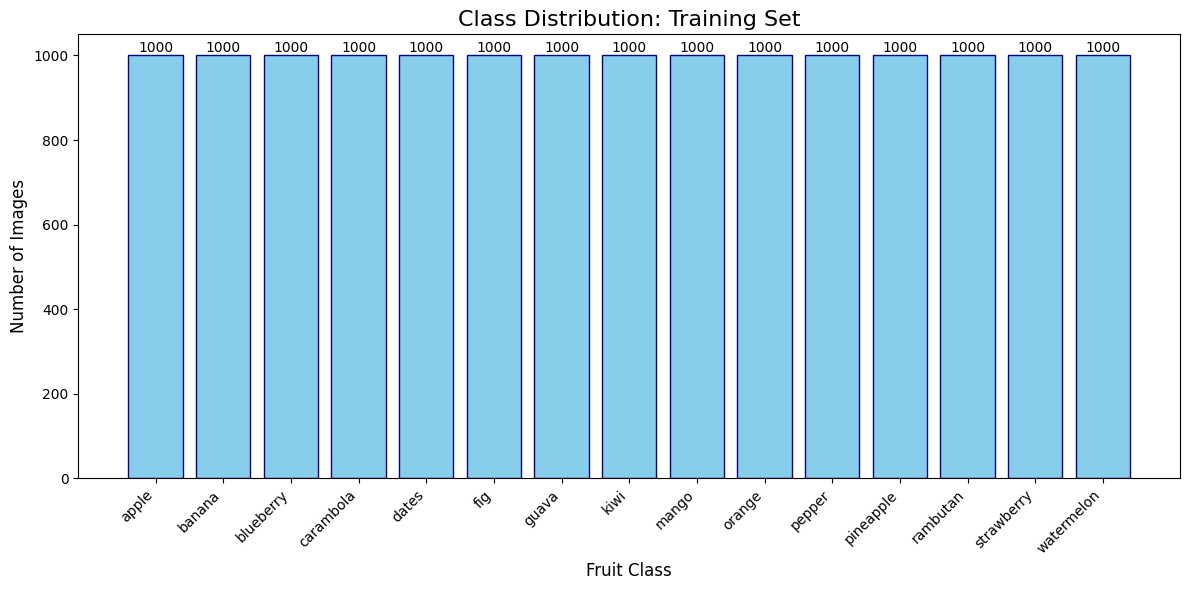

In [ ]:
# See class distribution of Trainig Data After Image Augmentation
visualize_class_distribution(TRAIN_DIR, "Training Set")


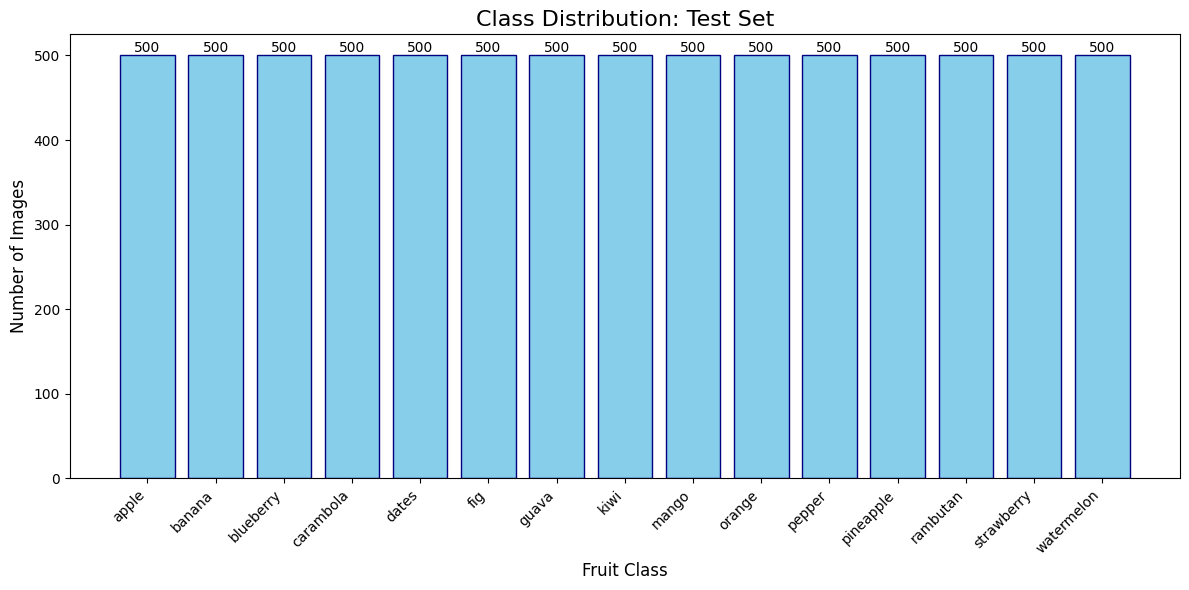

In [ ]:
# See class distribution of Test Data After Image Augmentation
visualize_class_distribution(TEST_DIR, "Test Set")


In [ ]:
def visualize_augmented_samples(
    dataset_path="", set_name="Augmented Samples", seed=None
):
    """
    Displays one random AUGMENTED sample (aug_*) from each class folder.

    Falls back to original image if no augmented image exists.

    Args:
        dataset_path: Path to dataset (TRAIN_DIR or TEST_DIR)
        set_name: Title for the plot
        seed: Optional seed for reproducibility
    """

    if seed is not None:
        random.seed(seed)

    classes = sorted(
        [
            d
            for d in os.listdir(dataset_path)
            if os.path.isdir(os.path.join(dataset_path, d))
        ]
    )

    num_classes = len(classes)

    cols = 5
    rows = (num_classes // cols) + (1 if num_classes % cols != 0 else 0)

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
    fig.suptitle(f"{set_name}", fontsize=20, y=1.02)

    axes = axes.flatten()

    for i, class_name in enumerate(classes):
        class_folder = os.path.join(dataset_path, class_name)

        all_images = [
            f
            for f in os.listdir(class_folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        # Filter augmented images
        aug_images = [f for f in all_images if f.startswith("aug_")]

        # Prefer augmented images, fallback to original
        chosen_list = aug_images if aug_images else all_images

        if chosen_list:
            img_path = os.path.join(class_folder, random.choice(chosen_list))
            img = Image.open(img_path)

            axes[i].imshow(img)
            axes[i].set_title(
                f"{class_name}\n({'aug' if chosen_list == aug_images else 'orig'})"
            )

        axes[i].axis("off")

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


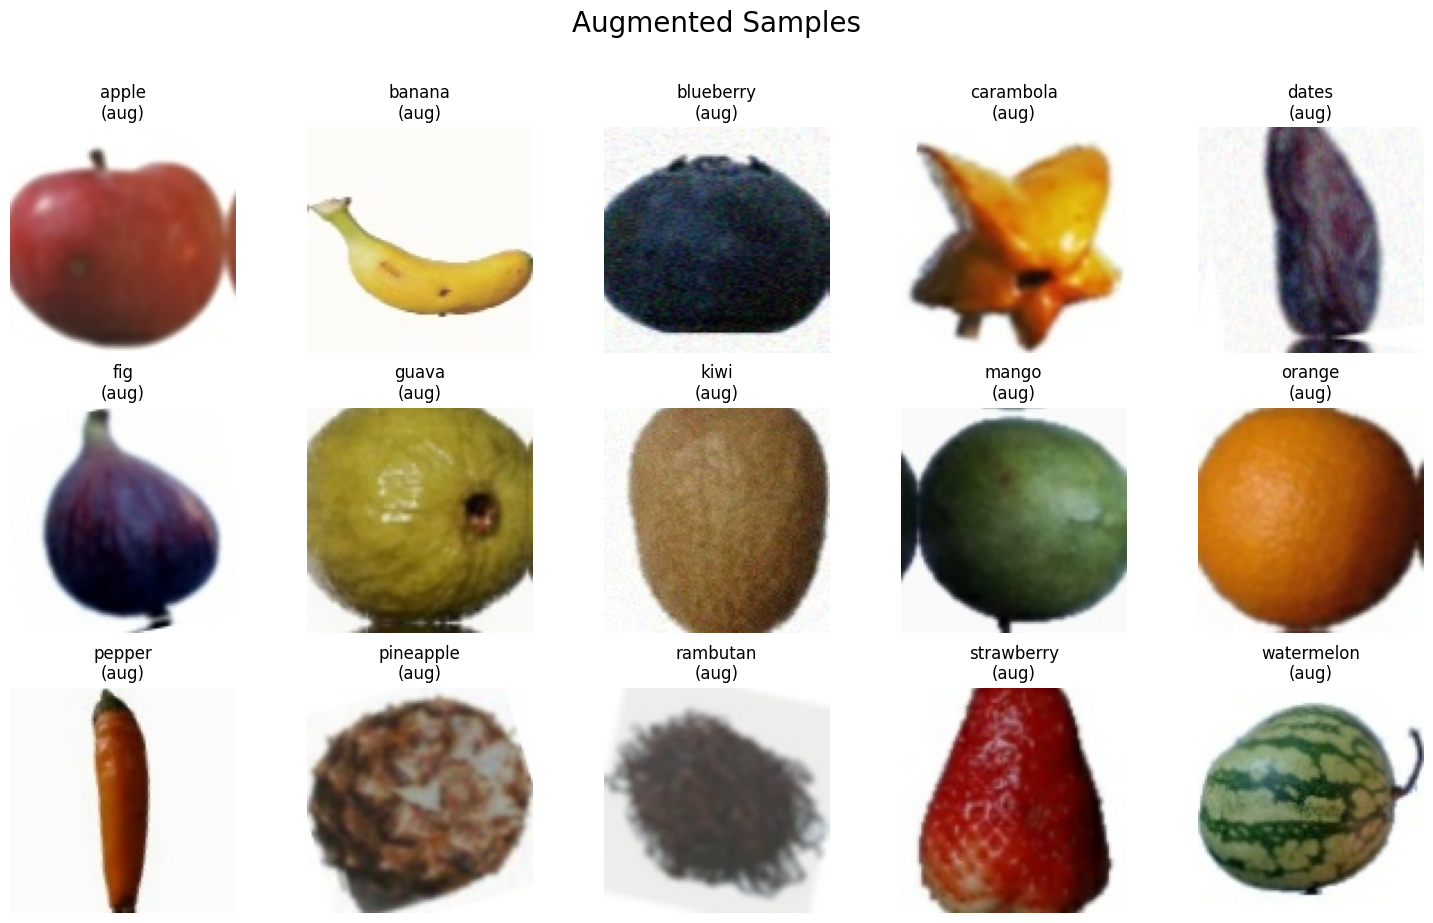

In [ ]:
# visualize_random_samples(TRAIN_DIR, "Original Mix")
visualize_augmented_samples(TRAIN_DIR)


---


# Base-line Model

In [ ]:
from keras import layers, models
from keras.layers import Input, Rescaling

from keras.utils import image_dataset_from_directory

from sklearn.metrics import classification_report

from keras.callbacks import ModelCheckpoint, EarlyStopping


In [ ]:
BASELINE_IMG_HEIGHT = 128
BASELINE_IMG_WIDTH = 128
BASELINE_BATCH_SIZE = 32
BASELINE_VALIDATION_SPLIT = 0.2
BASELINE_EPOCHS = 20
BASELINE_SEED = 42


In [ ]:
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(BASELINE_IMG_HEIGHT, BASELINE_IMG_WIDTH),
    interpolation="bilinear",
    batch_size=BASELINE_BATCH_SIZE,
    shuffle=True,
    validation_split=BASELINE_VALIDATION_SPLIT,
    subset="training",
    seed=BASELINE_SEED,
)

val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(BASELINE_IMG_HEIGHT, BASELINE_IMG_WIDTH),
    interpolation="bilinear",
    batch_size=BASELINE_BATCH_SIZE,
    shuffle=False,
    validation_split=BASELINE_VALIDATION_SPLIT,
    subset="validation",
    seed=BASELINE_SEED,
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(BASELINE_IMG_HEIGHT, BASELINE_IMG_WIDTH),
    interpolation="bilinear",
    batch_size=BASELINE_BATCH_SIZE,
    shuffle=False,
)

# Performance boost
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


Found 15000 files belonging to 15 classes.
Using 12000 files for training.
Found 15000 files belonging to 15 classes.
Using 3000 files for validation.
Found 7500 files belonging to 15 classes.


In [ ]:
model = models.Sequential(
    [
        # Input
        Input(shape=(BASELINE_IMG_HEIGHT, BASELINE_IMG_WIDTH, 3), name="input"),
        # Rescale
        layers.Rescaling(1.0 / 255),
        # Conv Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        # Conv Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        # Conv Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        # Flatten
        layers.Flatten(),
        # Fully Connected Layers
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        # Output Layer
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ]
)


In [ ]:
# Compile the model with optimizer, loss function and metrics
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print("Model Compiled Successfully!")


Model Compiled Successfully!


In [ ]:
# Callback to model with highest accuracy
checkpoint_cb = ModelCheckpoint(
    filepath="callback_accuracy.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

# Callback to model when loss stops decreasing
early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1,
)


In [ ]:
# Train the model wiht all configurations
history = model.fit(
    train_ds,
    epochs=BASELINE_EPOCHS,
    batch_size=BASELINE_BATCH_SIZE,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
)


Epoch 1/20
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6800 - loss: 0.9671
Epoch 1: val_accuracy improved from -inf to 0.99467, saving model to callback_accuracy.h5


375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6810 - loss: 0.9641 - val_accuracy: 0.9947 - val_loss: 0.0167
Epoch 2/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9819 - loss: 0.0544
Epoch 2: val_accuracy did not improve from 0.99467
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9819 - loss: 0.0543 - val_accuracy: 0.9900 - val_loss: 0.0319
Epoch 3/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9684 - loss: 0.1069
Epoch 3: val_accuracy did not improve from 0.99467
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9685 - loss: 0.1065 - val_accuracy: 0.9853 - val_loss: 0.0372
Epoch 4/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9948 - loss: 0.0178
Epoch 4: val_accuracy did not improve from 0.99467
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9947 - loss: 0.0178 - val_accuracy: 0.9843 - val_loss: 0.0419
Epoch 5/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9779 - loss: 0.0728
Epoch 5: val_accuracy impr

375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9780 - loss: 0.0725 - val_accuracy: 0.9983 - val_loss: 0.0069
Epoch 6/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9958 - loss: 0.0129
Epoch 6: val_accuracy did not improve from 0.99833
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9958 - loss: 0.0130 - val_accuracy: 0.9950 - val_loss: 0.0118
Epoch 7/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9820 - loss: 0.0594
Epoch 7: val_accuracy did not improve from 0.99833
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9821 - loss: 0.0593 - val_accuracy: 0.9937 - val_loss: 0.0164
Epoch 8/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9981 - loss: 0.0064
Epoch 8: val_accuracy did not improve from 0.99833
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9981 - loss: 0.0064 - val_accuracy: 0.9930 - val_loss: 0.0235
Epoch 9/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9860 - loss: 0.0525
Epoch 9: val_accuracy did n

375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 3.2808e-04
Epoch 11/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9991 - loss: 0.0033
Epoch 11: val_accuracy did not improve from 1.00000
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 1.5566e-04
Epoch 12/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9935 - loss: 0.0232
Epoch 12: val_accuracy did not improve from 1.00000
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9935 - loss: 0.0234 - val_accuracy: 0.9790 - val_loss: 0.0703
Epoch 13/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9888 - loss: 0.0377
Epoch 13: val_accuracy did not improve from 1.00000
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9888 - loss: 0.0376 - val_accuracy: 0.9993 - val_loss: 0.0021
Epoch 14/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9995 - loss: 0.0011
Epoch 14: va

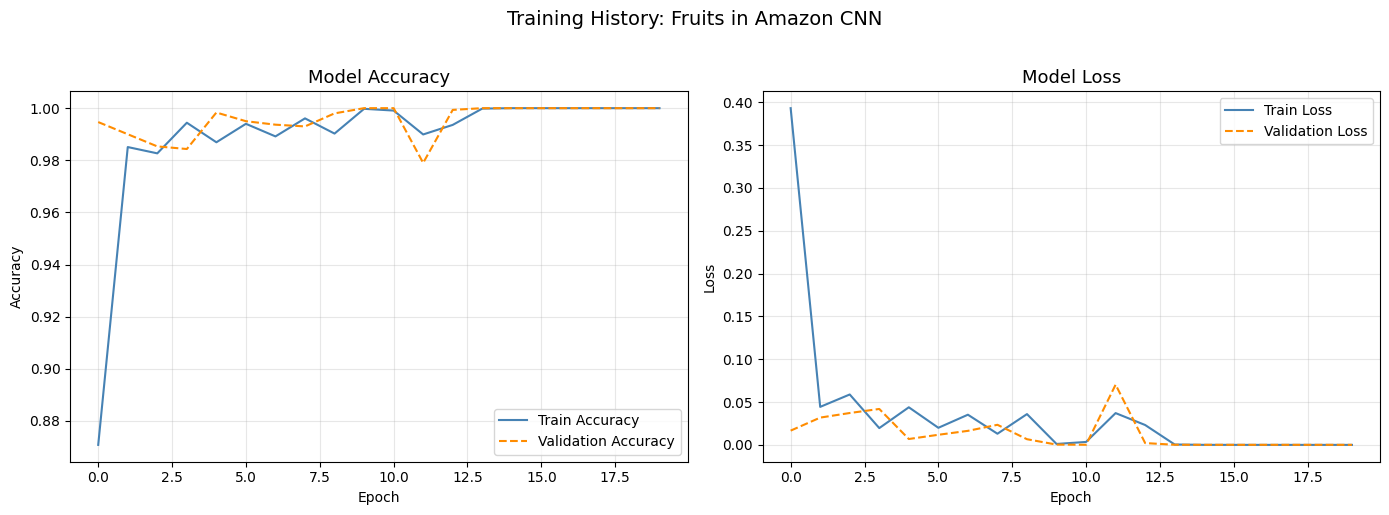

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history["accuracy"], label="Train Accuracy", color="steelblue")
ax1.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    color="darkorange",
    linestyle="--",
)
ax1.set_title("Model Accuracy", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history["loss"], label="Train Loss", color="steelblue")
ax2.plot(
    history.history["val_loss"],
    label="Validation Loss",
    color="darkorange",
    linestyle="--",
)
ax2.set_title("Model Loss", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Training History: Fruits in Amazon CNN", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")


235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9972 - loss: 0.0080

Test Loss     : 0.0097
Test Accuracy : 0.9977


In [ ]:
# Collect true labels and predictions from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [ ]:
# Classification Report
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=2,
)
print("Classification Report\n")
print(report)


Classification Report

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       500
   carambola       1.00      0.99      0.99       500
       guava       1.00      1.00      1.00       500
      orange       1.00      1.00      1.00       500
    rambutan       1.00      1.00      1.00       500
      banana       1.00      1.00      1.00       500
       dates       1.00      1.00      1.00       500
        kiwi       1.00      1.00      1.00       500
      pepper       1.00      1.00      1.00       500
  strawberry       1.00      1.00      1.00       500
   blueberry       0.98      1.00      0.99       500
         fig       1.00      1.00      1.00       500
       mango       1.00      1.00      1.00       500
   pineapple       1.00      0.99      0.99       500
  watermelon       1.00      1.00      1.00       500

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
wei

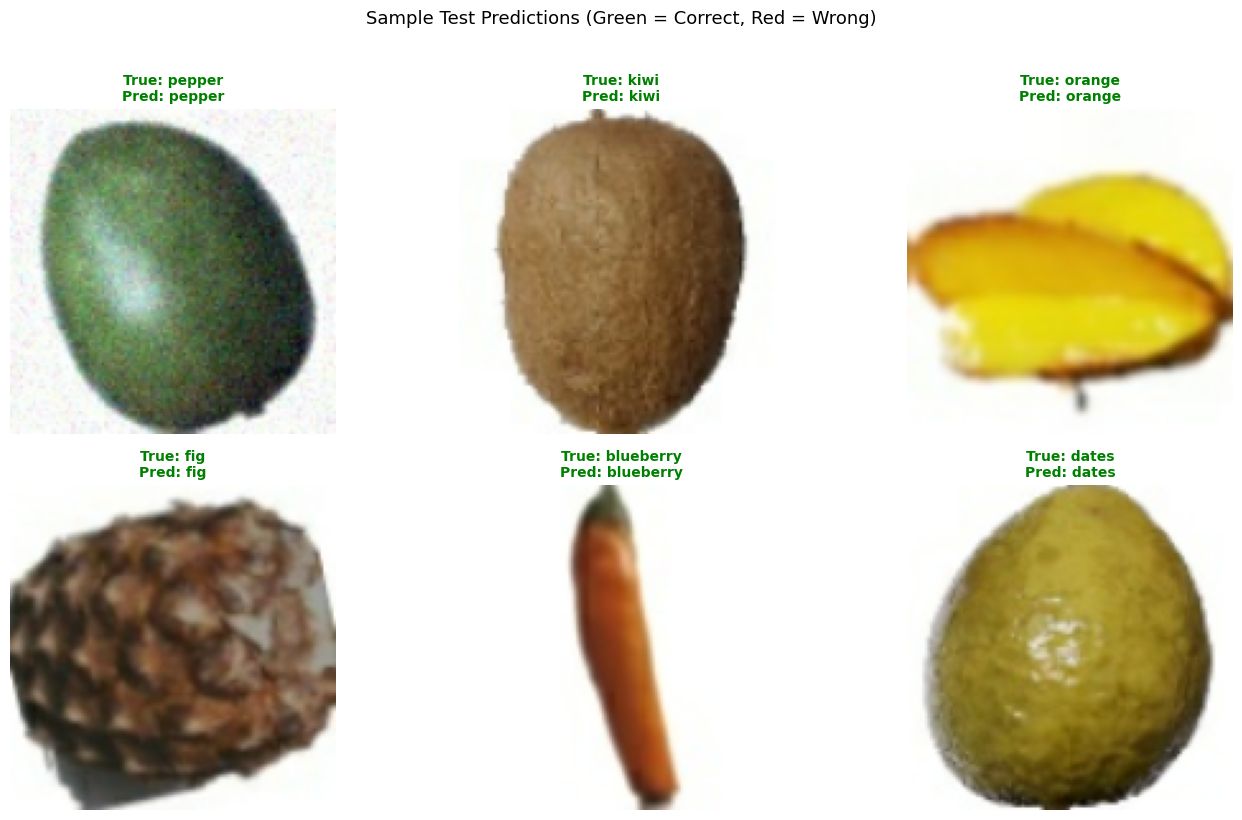

In [ ]:
# Collect images in same order as predictions
all_images = []
all_labels = []

for images, labels in test_ds:
    all_images.extend(images.numpy())
    all_labels.extend(labels.numpy())

all_images = np.array(all_images)
all_labels = np.array(all_labels)

# Pick 6 random indices
sample_idx = np.random.choice(len(all_images), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    img = all_images[idx]
    true_label = CLASS_NAMES[all_labels[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]

    color = "green" if pred_label == true_label else "red"

    axes[i].imshow(img.astype("uint8"))
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}",
        fontsize=10,
        color=color,
        fontweight="bold",
    )
    axes[i].axis("off")

plt.suptitle(
    "Sample Test Predictions (Green = Correct, Red = Wrong)", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()
